# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  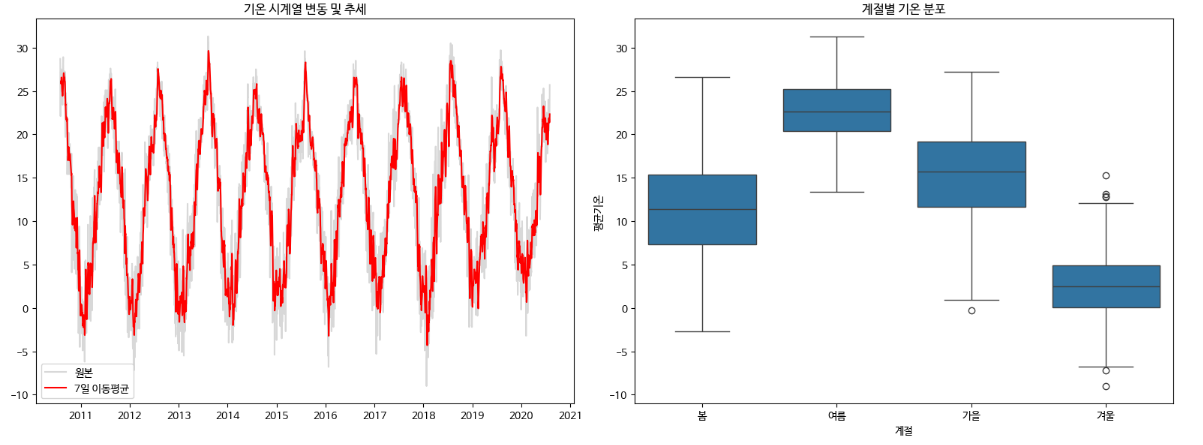

  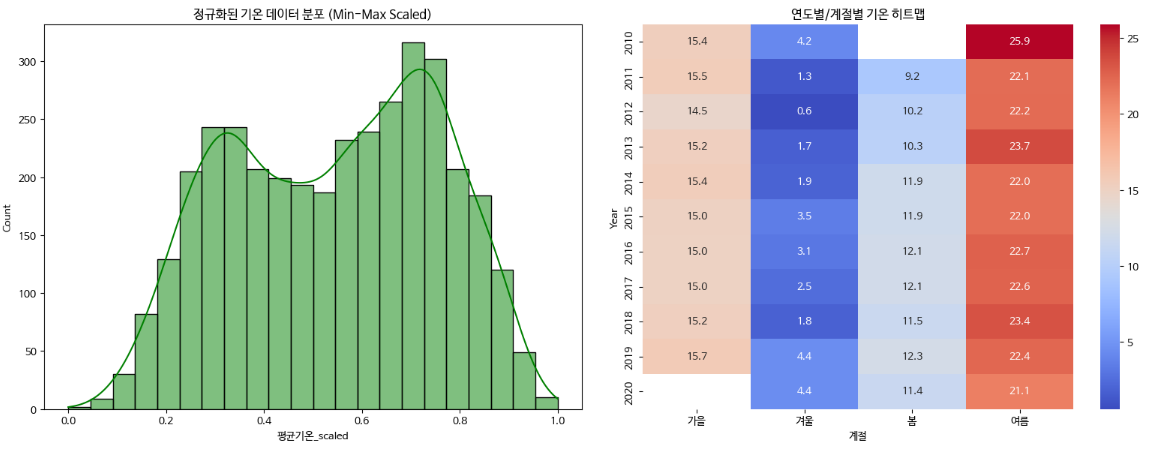



✅ 환경 설정 및 한글 폰트 로드 완료


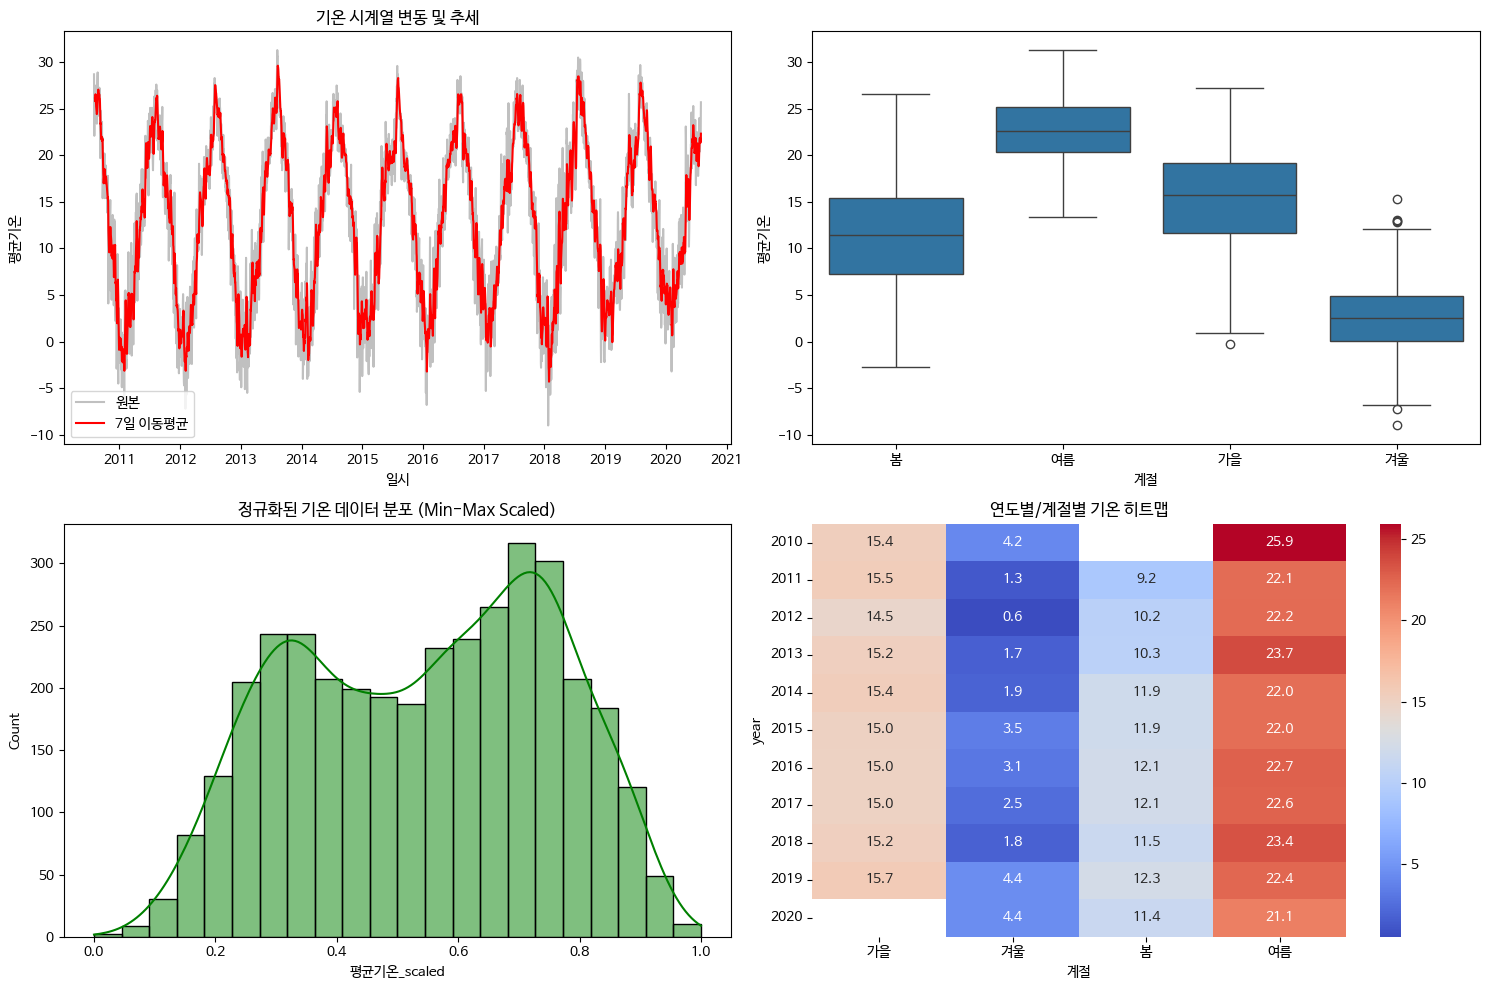

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import os
import warnings

# ---------------------------------------------------------
# 1. 환경 및 폰트 설정
#-------------------------------------------------------------
def setup_environment():
    warnings.filterwarnings('ignore')

    # 1. 시스템에 나눔 폰트가 있는지 확인 및 설치
    font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
    if not os.path.exists(font_path):
        # Colab 등 리눅스 환경에서 폰트 설치
        os.system('sudo apt-get install -y fonts-nanum > /dev/null')

    # 2. 폰트 매니저에 등록
    if os.path.exists(font_path):
        fm.fontManager.addfont(font_path)
        plt.rc('font', family='NanumBarunGothic')
    else:
        # 윈도우 환경인 경우 'Malgun Gothic'
        plt.rc('font', family='Malgun Gothic' if os.name == 'nt' else 'AppleGothic')

    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 환경 설정 및 한글 폰트 로드 완료")

setup_environment()

path = 'https://github.com/dongupak/DataML/raw/main/csv/'
df = pd.read_csv(path + 'weather.csv', encoding='CP949')
df["7day_avg"]= df['평균기온'].rolling(window=7).mean()
df['일시'] = pd.to_datetime(df['일시'])


df.set_index('일시', inplace=True)
df['month'] = df.index.month
df['year'] = df.index.year
season_names = {1:'겨울',2:'겨울',3:'봄',4:'봄',5:'봄',6:'여름',7:'여름',8:'여름',9:'가을',10:'가을',11:'가을',12:'겨울'}
df['계절']= df.index.month.map(season_names)
ordered_season = ['봄', '여름', '가을', '겨울']
season_temp_mean = df.groupby('계절')['평균기온'].mean()


def min_max_scale(series):
  result = (series - series.min()) / (series.max() - series.min())
  return result

df['평균기온_scaled'] =min_max_scale(df['평균기온'])

heatmap_data =df.pivot_table(values='평균기온',
index='year',columns='계절', aggfunc='mean')

heatmap_data = heatmap_data.sort_index(ascending=True)


plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
sns.lineplot(data=df["평균기온"],label="원본", color='silver')
sns.lineplot(data=df["7day_avg"],label="7일 이동평균",color='red' )
plt.title("기온 시계열 변동 및 추세")
plt.legend(loc='lower left')
plt.subplot(2,2,2)
sns.boxplot(data=df, x='계절', y='평균기온', order=ordered_season)
plt.subplot(2,2,3)
sns.histplot(df['평균기온_scaled'], kde=True, color='green')
plt.title("정규화된 기온 데이터 분포 (Min-Max Scaled)")
plt.subplot(2,2,4)
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("연도별/계절별 기온 히트맵")
plt.tight_layout()
plt.show

file_name = 'weather_analysis_report.xlsx'
with pd.ExcelWriter("weather_analysis_report.xlsx") as f:

 df.to_excel(f, sheet_name="전처리 데이터", index=False)
 season_stats = season_temp_mean.reindex(ordered_season).to_frame(name='계절별 평균기온')
 season_stats.to_excel(f, sheet_name='계절별 통계')
 heatmap_data.to_excel(f, sheet_name='연도별 피벗 테이블', index=True)


